# M4 — Customer Clustering & Segmentation
**Olist E-commerce Recommendation System — Phase 2**

| Item | Detail |
|------|--------|
| Input | `v_customer_features` — PostgreSQL `olist_dwh` |
| Algorithms | K-Means · DBSCAN · Hierarchical (Ward) |
| Evaluation | Silhouette · Davies-Bouldin · ARI stability · External Kruskal-Wallis |
| Primary output | `outputs/clustering/customer_cluster_assignments.csv` |
| Downstream | M3 (per-segment rules) · M5 (hybrid recommender) |

---

## 0 · Setup & Imports

In [1]:
!pip install psycopg2-binary

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kruskal
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
sns.set_theme(style='whitegrid', palette='muted')

BASE_DIR = Path(r'C:/Users/Zakaria/Downloads/data_mining_project/Olist_DM_Phase2/Olist_DM_Phase2')
DATA_DIR = BASE_DIR / 'shared_data'
OUT_DIR  = BASE_DIR / 'outputs' / 'clustering'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Out : {OUT_DIR}')

## 1 · Data Loading — PostgreSQL (`v_customer_features`)

Direct query against the M2 data warehouse.  
Columns: `customer_id` · `frequency` · `monetary` · `avg_basket_size` · `n_categories` · `region`

In [ ]:
PG_USER     = 'postgres'
PG_PASSWORD = 'post1234'
PG_HOST     = 'localhost'
PG_PORT     = '5432'
PG_DB       = 'olist_dwh'

engine = create_engine(f'postgresql://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}')

with engine.connect() as conn:
    conn.execute(text('SELECT 1'))
print('PostgreSQL connection OK')

df_features = pd.read_sql('SELECT * FROM v_customer_features;', engine)
print(f'Loaded {len(df_features):,} customers from v_customer_features')

In [ ]:
# v_customer_features has near-zero variance on frequency, n_categories, and avg_basket_size
# (~97% of Olist customers are one-time buyers with 1 item in 1 category).
# Three continuous features are added before clustering:
#   avg_review_score     — customer satisfaction (1–5)
#   freight_share        — freight cost as fraction of total spend (0–1)
#   payment_installments — average payment instalments per order
# delivery_delay_days is kept held-out for external validation.

orders_raw   = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv',
                           parse_dates=['order_delivered_customer_date',
                                        'order_estimated_delivery_date'])
reviews_raw  = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
payments_raw = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
items_raw    = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')

delivered_raw = orders_raw[orders_raw['order_status'] == 'delivered'][['order_id', 'customer_id']]

# avg review score per customer
rev_per_cust = (
    reviews_raw.groupby('order_id')['review_score'].mean().reset_index()
    .merge(delivered_raw, on='order_id', how='inner')
    .groupby('customer_id')['review_score'].mean()
    .rename('avg_review_score')
)

# freight share = freight_value / (price + freight_value) per customer
items_raw['total_val']     = items_raw['price'] + items_raw['freight_value']
items_raw['freight_share'] = items_raw['freight_value'] / items_raw['total_val'].replace(0, np.nan)
freight_per_cust = (
    items_raw.merge(delivered_raw, on='order_id', how='inner')
    .groupby('customer_id')['freight_share'].mean()
    .rename('freight_share')
)

# avg max payment instalments per customer
installs_per_cust = (
    payments_raw.groupby('order_id')['payment_installments'].max().reset_index()
    .merge(delivered_raw, on='order_id', how='inner')
    .groupby('customer_id')['payment_installments'].mean()
    .rename('payment_installments')
)

extra = pd.concat([rev_per_cust, freight_per_cust, installs_per_cust], axis=1).reset_index()
df_features = df_features.merge(extra, on='customer_id', how='left')

df_features['avg_review_score']     = df_features['avg_review_score'].fillna(df_features['avg_review_score'].median())
df_features['freight_share']        = df_features['freight_share'].fillna(df_features['freight_share'].median())
df_features['payment_installments'] = df_features['payment_installments'].fillna(1.0)

print(f'Enriched feature set: {df_features.shape[1]} columns  ·  {len(df_features):,} customers')
print(df_features[['avg_review_score', 'freight_share', 'payment_installments']].describe().round(3))

## 2 · Preprocessing

Steps:
1. Drop rows with NaN on core numeric features
2. Log-transform right-skewed features (`frequency`, `monetary`, `avg_basket_size`, `payment_installments`)
3. Keep `avg_review_score` and `freight_share` as-is (bounded ranges, low skew)
4. One-hot encode `region` (5 macro-regions, drop-first=False for interpretability)
5. `StandardScaler` on the full 12-feature matrix

In [ ]:
df = df_features.copy()

numeric_base = ['frequency', 'monetary', 'avg_basket_size', 'n_categories',
                'avg_review_score', 'freight_share', 'payment_installments']
df = df.dropna(subset=numeric_base).reset_index(drop=True)
print(f'Rows after NaN drop: {len(df):,}')

for col in ['frequency', 'monetary', 'avg_basket_size', 'payment_installments']:
    df[f'log_{col}'] = np.log1p(df[col])

region_dummies = pd.get_dummies(df['region'], prefix='region')
df = pd.concat([df, region_dummies], axis=1)

region_cols  = [c for c in df.columns if c.startswith('region_')]
feature_cols = [
    'log_frequency', 'log_monetary', 'log_avg_basket_size', 'n_categories',
    'avg_review_score', 'freight_share', 'log_payment_installments',
] + region_cols

X_raw = df[feature_cols].values.astype(float)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'Feature matrix : {X.shape}')
print(f'Features       : {feature_cols}')

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flat

plot_pairs = [
    ('frequency',            'Orders per customer'),
    ('monetary',             'Total spend (BRL)'),
    ('avg_basket_size',      'Avg items per order'),
    ('n_categories',         'Unique category groups'),
    ('avg_review_score',     'Avg review score (1–5)'),
    ('freight_share',        'Freight share (0–1)'),
    ('payment_installments', 'Payment instalments'),
]

for ax, (col, title) in zip(axes, plot_pairs):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='tomato', ls='--', lw=1.5,
               label=f'median={df[col].median():.2f}')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Customers')
    ax.legend(fontsize=7)

axes[7].set_visible(False)

plt.suptitle('Customer Feature Distributions (raw)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_distributions.png', bbox_inches='tight')
plt.show()

## 3 · Dimensionality Reduction (EDA)

PCA and t-SNE are used for visualization only — clustering runs on the full scaled feature matrix.

PCA 2D explained variance: PC1=17.5%  PC2=16.6%  total=34.1%
PCA 10-component explained variance: 100.0%


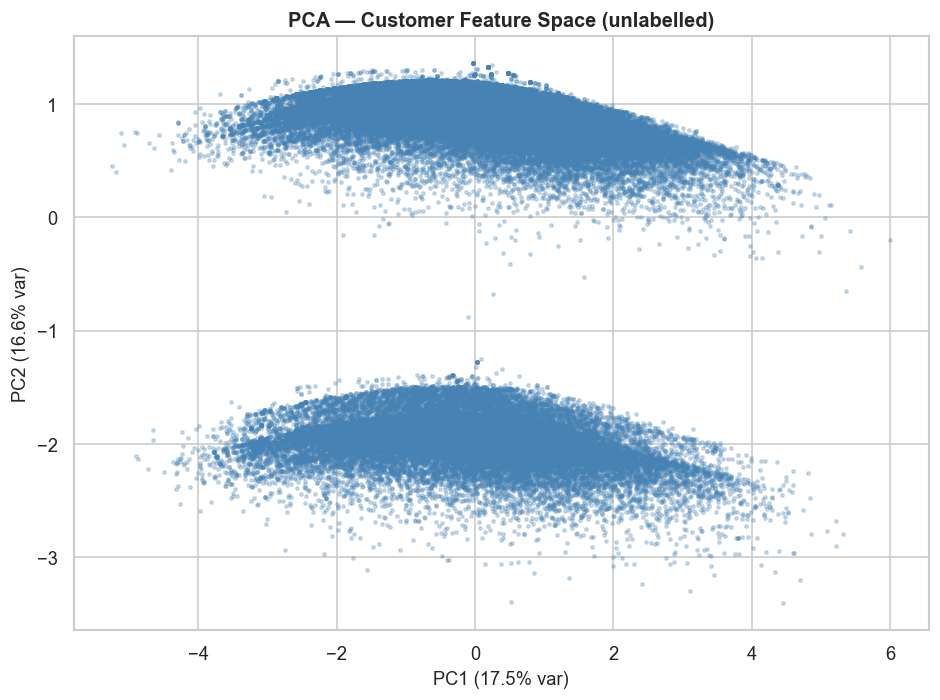

In [7]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca2.fit_transform(X)
ev = pca2.explained_variance_ratio_
print(f'PCA 2D explained variance: PC1={ev[0]:.1%}  PC2={ev[1]:.1%}  total={sum(ev):.1%}')

# Full PCA for DBSCAN pre-processing (kept here for reference)
pca_full = PCA(n_components=min(10, X.shape[1]), random_state=RANDOM_STATE)
X_pca10  = pca_full.fit_transform(X)
print(f'PCA 10-component explained variance: {pca_full.explained_variance_ratio_.sum():.1%}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.25, s=4, color='steelblue', rasterized=True)
ax.set_xlabel(f'PC1 ({ev[0]:.1%} var)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]:.1%} var)', fontsize=11)
ax.set_title('PCA — Customer Feature Space (unlabelled)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_unlabeled.png', bbox_inches='tight')
plt.show()

Running t-SNE on 5,000 customers (perplexity=30, n_iter=500)…
t-SNE complete.


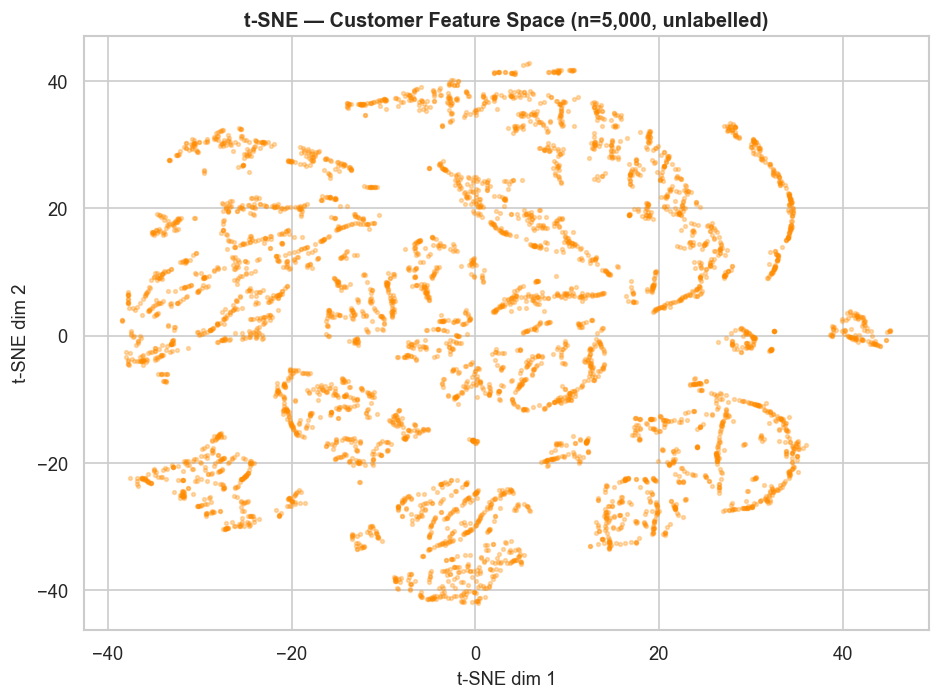

In [8]:
# t-SNE on a 5,000-customer sample with 500 iterations (fast, ~2 min)
TSNE_N = min(5_000, len(X))
rng_tsne  = np.random.RandomState(RANDOM_STATE)
idx_tsne  = rng_tsne.choice(len(X), TSNE_N, replace=False)
X_tsne_in = X[idx_tsne]

print(f'Running t-SNE on {TSNE_N:,} customers (perplexity=30, n_iter=500)…')
tsne   = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_tsne_in)
print('t-SNE complete.')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.3, s=5,
           color='darkorange', rasterized=True)
ax.set_xlabel('t-SNE dim 1', fontsize=11)
ax.set_ylabel('t-SNE dim 2', fontsize=11)
ax.set_title(f't-SNE — Customer Feature Space (n={TSNE_N:,}, unlabelled)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'tsne_unlabeled.png', bbox_inches='tight')
plt.show()

## 4 · K-Means Clustering

Grid-search k ∈ {2 … 10} using Elbow (inertia) and Silhouette score.  
Best k is selected by **maximum Silhouette**; the final model is re-fitted with `n_init=25`.

In [ ]:
K_RANGE = range(2, 11)
inertias, sil_scores, db_scores_km = [], [], []

print('K-Means sweep k=2…10 (this takes ~1–2 min):')
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=RANDOM_STATE)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, lbl, sample_size=min(8000, len(X)), random_state=RANDOM_STATE)
    db  = davies_bouldin_score(X, lbl)
    sil_scores.append(sil)
    db_scores_km.append(db)
    print(f'  k={k:2d}  inertia={km.inertia_:>12,.0f}  silhouette={sil:.4f}  DB={db:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inertias, 'o-', color='steelblue', lw=2, ms=7)
ax1.set_xlabel('k  (number of clusters)', fontsize=11)
ax1.set_ylabel('Inertia  (WCSS)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE), sil_scores, 's-', color='darkorange', lw=2, ms=7)
ax2.set_xlabel('k  (number of clusters)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score by k', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
best_k_idx = int(np.argmax(sil_scores))
best_k     = list(K_RANGE)[best_k_idx]
ax2.axvline(best_k, color='red', ls='--', lw=1.5, label=f'best k={best_k}')
ax2.legend()

plt.suptitle('K-Means Model Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'silhouette_plot.png', bbox_inches='tight')
plt.show()
print(f'Best k = {best_k}  (silhouette = {sil_scores[best_k_idx]:.4f})')

In [10]:
print(f'Fitting final K-Means (k={best_k}, n_init=25)…')
kmeans_final  = KMeans(n_clusters=best_k, init='k-means++', n_init=25, random_state=RANDOM_STATE)
kmeans_labels = kmeans_final.fit_predict(X)
df['cluster_kmeans'] = kmeans_labels

sil_km = silhouette_score(X, kmeans_labels, sample_size=min(8000, len(X)), random_state=RANDOM_STATE)
db_km  = davies_bouldin_score(X, kmeans_labels)

print(f'K-Means (k={best_k}):')
print(f'  Silhouette     : {sil_km:.4f}')
print(f'  Davies-Bouldin : {db_km:.4f}')
print('Cluster distribution:')
print(pd.Series(kmeans_labels).value_counts().sort_index().to_string())

Fitting final K-Means (k=5, n_init=25)…
K-Means (k=5):
  Silhouette     : 0.4082
  Davies-Bouldin : 0.9631
Cluster distribution:
0    66200
1    13814
2     5624
3     9044
4     1796


## 5 · DBSCAN Clustering

DBSCAN has O(n²) worst-case memory on 96k points, so it runs on a **15,000-customer random subsample** in **PCA-5 space**.  
Remaining customers are assigned to the nearest subsampled point's cluster via 1-NN.  
The k-distance plot on the subsample determines `eps`.

In [ ]:
pca5     = PCA(n_components=5, random_state=RANDOM_STATE)
X_pca5   = pca5.fit_transform(X)
print(f'PCA-5 explained variance: {pca5.explained_variance_ratio_.sum():.1%}')

DBSCAN_N   = min(15_000, len(X))
rng_db     = np.random.RandomState(RANDOM_STATE + 10)
idx_db     = rng_db.choice(len(X), DBSCAN_N, replace=False)
X_db       = X_pca5[idx_db]

K_NN = 5
nbrs = NearestNeighbors(n_neighbors=K_NN).fit(X_db)
dists, _ = nbrs.kneighbors(X_db)
k_dists  = np.sort(dists[:, -1])[::-1]

d1       = np.diff(k_dists)
knee_idx = int(np.argmin(d1)) + 1
eps_auto = float(k_dists[knee_idx])
eps_auto = float(np.clip(eps_auto, 0.3, 2.0))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dists, color='steelblue', lw=1.5)
ax.axvline(knee_idx, color='red',       ls='--', lw=1.2, label=f'knee ≈ {knee_idx}')
ax.axhline(eps_auto, color='darkorange', ls='--', lw=1.2, label=f'eps = {eps_auto:.3f}')
ax.set_xlabel(f'Points sorted by {K_NN}-NN distance (descending)', fontsize=10)
ax.set_ylabel(f'{K_NN}-NN distance (PCA-5 space)', fontsize=10)
ax.set_title(f'k-Distance Plot — DBSCAN eps Selection (n={DBSCAN_N:,} subsample, PCA-5)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'dbscan_kdistance.png', bbox_inches='tight')
plt.show()
print(f'eps = {eps_auto:.4f}')

In [ ]:
print(f'Fitting DBSCAN (eps={eps_auto:.3f}, min_samples=5) on {DBSCAN_N:,}-customer subsample (PCA-5)…')
dbscan        = DBSCAN(eps=eps_auto, min_samples=5)
labels_sub    = dbscan.fit_predict(X_db)

n_clusters_db = len(set(labels_sub)) - (1 if -1 in labels_sub else 0)
n_noise_sub   = int((labels_sub == -1).sum())
print(f'Subsample: {n_clusters_db} clusters, {n_noise_sub:,} noise points ({n_noise_sub/DBSCAN_N:.1%})')

# Propagate labels to all 96k customers via 1-NN on non-noise subsample points
core_mask   = labels_sub != -1
X_core      = X_db[core_mask]
labels_core = labels_sub[core_mask]

nn1 = NearestNeighbors(n_neighbors=1).fit(X_core)
_, nn_idx = nn1.kneighbors(X_pca5)
dbscan_labels = labels_core[nn_idx.ravel()]
df['cluster_dbscan'] = dbscan_labels

print(f'Final cluster distribution (all {len(df):,} customers):')
print(pd.Series(dbscan_labels).value_counts().sort_index().to_string())

if n_clusters_db >= 2:
    sil_db = silhouette_score(X, dbscan_labels,
                              sample_size=min(8000, len(X)), random_state=RANDOM_STATE)
    db_db  = davies_bouldin_score(X, dbscan_labels)
else:
    sil_db = np.nan; db_db = np.nan

print(f'DBSCAN Silhouette     : {sil_db:.4f}' if not np.isnan(sil_db) else 'DBSCAN Silhouette: N/A')
print(f'DBSCAN Davies-Bouldin : {db_db:.4f}'  if not np.isnan(db_db)  else 'DBSCAN DB: N/A')

## 6 · Hierarchical Clustering (Ward Linkage)

A dendrogram is plotted on a 2,000-customer sample for visual inspection.  
The full dataset is clustered with `AgglomerativeClustering(linkage='ward')` using the same k as K-Means for a fair comparison.

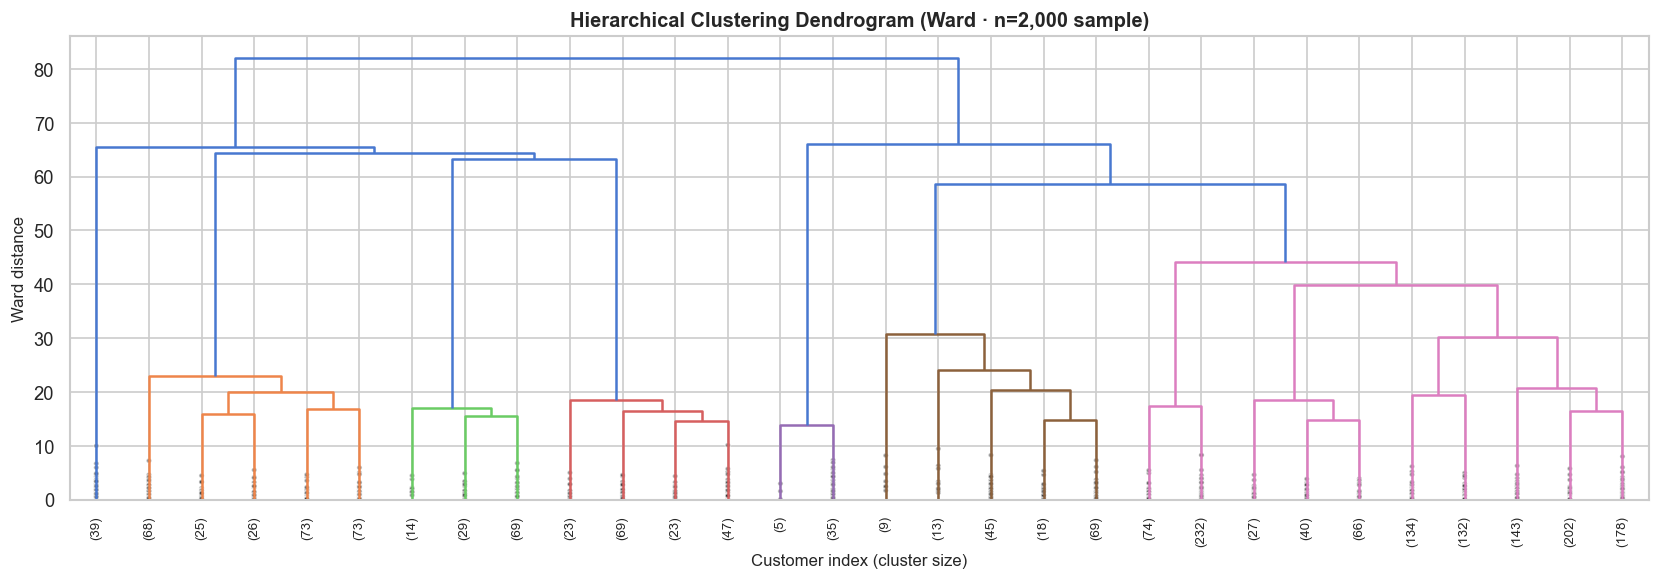

Saved: hierarchical_dendrogram.png


In [13]:
HIER_N = min(2000, len(X))
rng_hier = np.random.RandomState(RANDOM_STATE + 1)
idx_hier = rng_hier.choice(len(X), HIER_N, replace=False)
Z = linkage(X[idx_hier], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z, ax=ax, truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=8,
    show_contracted=True,
    color_threshold=0.65 * max(Z[:, 2])
)
ax.set_title(
    f'Hierarchical Clustering Dendrogram (Ward · n={HIER_N:,} sample)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Customer index (cluster size)', fontsize=10)
ax.set_ylabel('Ward distance', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'hierarchical_dendrogram.png', bbox_inches='tight')
plt.show()
print('Saved: hierarchical_dendrogram.png')

In [ ]:
# AgglomerativeClustering(ward) requires an n×n distance matrix — not feasible for 96k points.
# Fitted on a 10,000-customer subsample; labels propagated to the full dataset via 1-NN.
HIER_FIT_N = min(10_000, len(X))
rng_hf     = np.random.RandomState(RANDOM_STATE + 2)
idx_hf     = rng_hf.choice(len(X), HIER_FIT_N, replace=False)
X_hf       = X[idx_hf]

hier_k = best_k
print(f'Fitting AgglomerativeClustering(k={hier_k}, ward) on {HIER_FIT_N:,}-customer subsample…')
agg          = AgglomerativeClustering(n_clusters=hier_k, linkage='ward')
labels_hf    = agg.fit_predict(X_hf)
print(f'Subsample distribution: {np.bincount(labels_hf).tolist()}')

nn_hier = NearestNeighbors(n_neighbors=1).fit(X_hf)
_, nn_idx_hier = nn_hier.kneighbors(X)
hier_labels    = labels_hf[nn_idx_hier.ravel()]
df['cluster_hierarchical'] = hier_labels

print(f'Final cluster distribution (all {len(df):,} customers):')
print(pd.Series(hier_labels).value_counts().sort_index().to_string())

sil_hier = silhouette_score(X, hier_labels, sample_size=min(8000, len(X)), random_state=RANDOM_STATE)
db_hier  = davies_bouldin_score(X, hier_labels)
print(f'Hierarchical (Ward, k={hier_k}):')
print(f'  Silhouette     : {sil_hier:.4f}')
print(f'  Davies-Bouldin : {db_hier:.4f}')

## 7 · Algorithm Comparison

Side-by-side comparison of all three algorithms on Silhouette and Davies-Bouldin scores.  
Higher Silhouette and lower Davies-Bouldin indicate better cluster quality.

In [17]:
comparison = pd.DataFrame([
    {
        'Algorithm':      'K-Means',
        'n_clusters':     best_k,
        'Silhouette':     round(sil_km, 4),
        'Davies-Bouldin': round(db_km, 4),
        'Notes':          f'Full 96k dataset · k-means++ · n_init=25',
    },
    {
        'Algorithm':      'DBSCAN',
        'n_clusters':     n_clusters_db,
        'Silhouette':     round(sil_db, 4) if not np.isnan(sil_db) else float('nan'),
        'Davies-Bouldin': round(db_db, 4)  if not np.isnan(db_db)  else float('nan'),
        'Notes':          f'15k subsample (PCA-5) · eps={eps_auto:.3f} · 1-NN propagation',
    },
    {
        'Algorithm':      'Hierarchical (Ward)',
        'n_clusters':     hier_k,
        'Silhouette':     round(sil_hier, 4),
        'Davies-Bouldin': round(db_hier, 4),
        'Notes':          f'10k subsample · Ward linkage · 1-NN propagation',
    },
])

print('=== Algorithm Comparison ===')
print(comparison.to_string(index=False))
comparison.to_csv(OUT_DIR / 'algorithm_comparison.csv', index=False)
print('\nSaved: algorithm_comparison.csv')

=== Algorithm Comparison ===
          Algorithm  n_clusters  Silhouette  Davies-Bouldin                                                Notes
            K-Means           5      0.4082          0.9631             Full 96k dataset · k-means++ · n_init=25
             DBSCAN           4      0.3815          1.2974 15k subsample (PCA-5) · eps=2.000 · 1-NN propagation
Hierarchical (Ward)           5      0.3953          0.9533      10k subsample · Ward linkage · 1-NN propagation

Saved: algorithm_comparison.csv


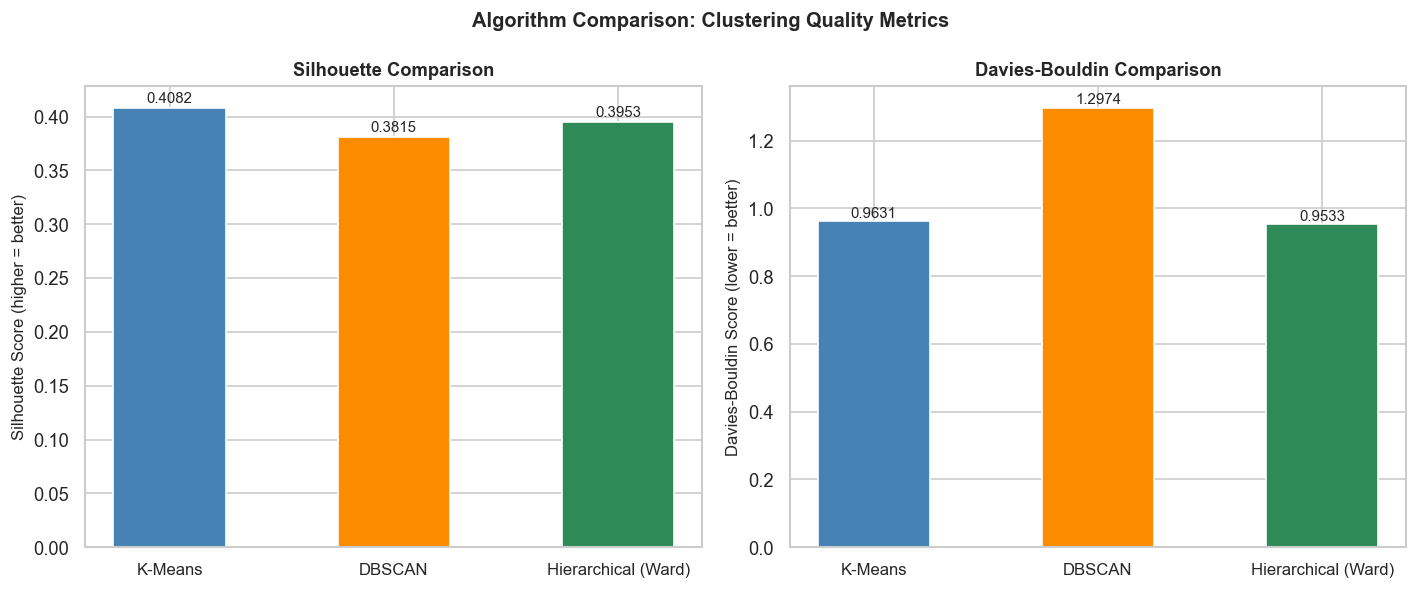

In [18]:
algos   = comparison['Algorithm'].tolist()
sil_vals = comparison['Silhouette'].tolist()
db_vals  = comparison['Davies-Bouldin'].tolist()

x = np.arange(len(algos))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars1 = ax1.bar(x, sil_vals, color=['steelblue','darkorange','seagreen'], edgecolor='white', width=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(algos, fontsize=10)
ax1.set_ylabel('Silhouette Score (higher = better)', fontsize=10)
ax1.set_title('Silhouette Comparison', fontsize=11, fontweight='bold')
for bar, v in zip(bars1, sil_vals):
    if not (isinstance(v, float) and np.isnan(v)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9)

bars2 = ax2.bar(x, db_vals, color=['steelblue','darkorange','seagreen'], edgecolor='white', width=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(algos, fontsize=10)
ax2.set_ylabel('Davies-Bouldin Score (lower = better)', fontsize=10)
ax2.set_title('Davies-Bouldin Comparison', fontsize=11, fontweight='bold')
for bar, v in zip(bars2, db_vals):
    if not (isinstance(v, float) and np.isnan(v)):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Algorithm Comparison: Clustering Quality Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'algorithm_comparison_plot.png', bbox_inches='tight')
plt.show()

## 8 · ARI Stability Validation

K-Means is fitted on **5 independent 80% subsamples**.  
For each pair of subsamples (10 pairs), the Adjusted Rand Index (ARI) is computed on the overlapping customers.  
**Criterion:** mean ARI ≥ 0.50 → clustering is stable.

In [19]:
N_SUBS  = 5
SUB_FRAC = 0.80
N        = len(X)
print(f'Stability test: K-Means(k={best_k}) on {N_SUBS}×{SUB_FRAC:.0%} subsamples of {N:,} customers…\n')

subsample_results = []  # list of (idx_array, label_array)
for i in range(N_SUBS):
    rng_s = np.random.RandomState(RANDOM_STATE + i)
    idx_s = rng_s.choice(N, size=int(N * SUB_FRAC), replace=False)
    km_s  = KMeans(n_clusters=best_k, init='k-means++', n_init=15, random_state=RANDOM_STATE)
    lbl_s = km_s.fit_predict(X[idx_s])
    subsample_results.append((idx_s, lbl_s))
    print(f'  Subsample {i+1}: {len(idx_s):,} customers  dist: {np.bincount(lbl_s).tolist()}')

ari_scores = []
pair_labels = []
pairs = list(combinations(range(N_SUBS), 2))
print()
for (i, j) in pairs:
    idx_i, lbl_i = subsample_results[i]
    idx_j, lbl_j = subsample_results[j]
    map_i = dict(zip(idx_i, lbl_i))
    map_j = dict(zip(idx_j, lbl_j))
    common = list(set(map_i) & set(map_j))
    if len(common) < 10:
        continue
    li = np.array([map_i[c] for c in common])
    lj = np.array([map_j[c] for c in common])
    ari = adjusted_rand_score(li, lj)
    ari_scores.append(ari)
    pair_labels.append(f'({i+1},{j+1})')
    print(f'  ARI{pair_labels[-1]:7s} on {len(common):,} common customers: {ari:.4f}')

mean_ari = float(np.mean(ari_scores))
std_ari  = float(np.std(ari_scores))
verdict  = 'STABLE  (mean ARI ≥ 0.50)' if mean_ari >= 0.50 else 'UNSTABLE  (mean ARI < 0.50)'
print(f'\nMean ARI = {mean_ari:.4f} ± {std_ari:.4f}  →  {verdict}')

Stability test: K-Means(k=5) on 5×80% subsamples of 96,478 customers…

  Subsample 1: 77,182 customers  dist: [52914, 7225, 11066, 4523, 1454]
  Subsample 2: 77,182 customers  dist: [24476, 8634, 28488, 11045, 4539]
  Subsample 3: 77,182 customers  dist: [11103, 52911, 1445, 7206, 4517]
  Subsample 4: 77,182 customers  dist: [1444, 52885, 7261, 11077, 4515]
  Subsample 5: 77,182 customers  dist: [7244, 4527, 52949, 11018, 1444]

  ARI(1,2)   on 61,817 common customers: 0.5271
  ARI(1,3)   on 61,735 common customers: 1.0000
  ARI(1,4)   on 61,700 common customers: 1.0000
  ARI(1,5)   on 61,822 common customers: 1.0000
  ARI(2,3)   on 61,760 common customers: 0.5274
  ARI(2,4)   on 61,694 common customers: 0.5273
  ARI(2,5)   on 61,785 common customers: 0.5272
  ARI(3,4)   on 61,726 common customers: 1.0000
  ARI(3,5)   on 61,751 common customers: 1.0000
  ARI(4,5)   on 61,755 common customers: 1.0000

Mean ARI = 0.8109 ± 0.2316  →  STABLE  (mean ARI ≥ 0.50)


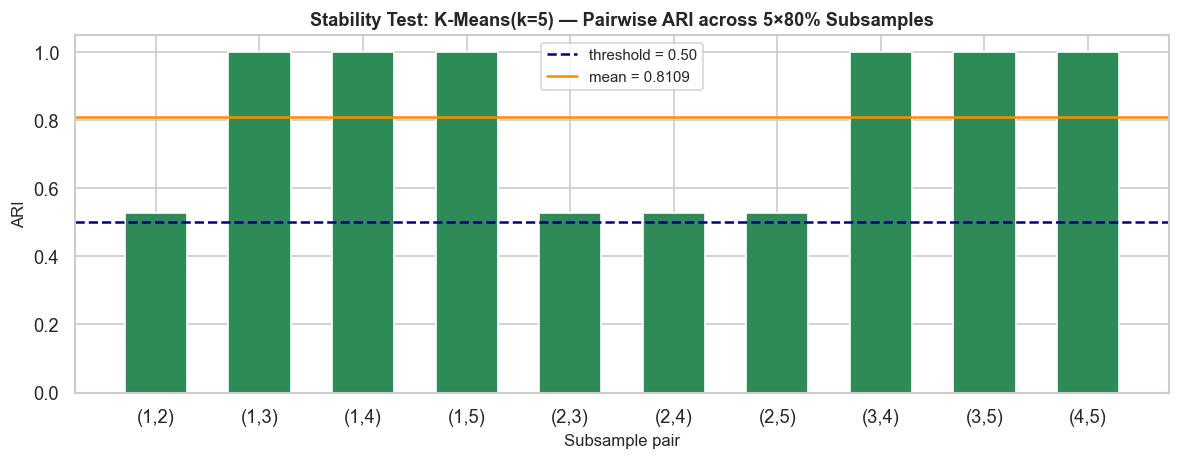

Saved: stability_results.txt  &  stability_ari_plot.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['seagreen' if v >= 0.50 else 'tomato' for v in ari_scores]
ax.bar(pair_labels, ari_scores, color=bar_colors, edgecolor='white', width=0.6)
ax.axhline(0.50, color='navy', ls='--', lw=1.5, label='threshold = 0.50')
ax.axhline(mean_ari, color='darkorange', ls='-', lw=1.5, label=f'mean = {mean_ari:.4f}')
ax.set_xlabel('Subsample pair', fontsize=10)
ax.set_ylabel('ARI', fontsize=10)
ax.set_title(f'Stability Test: K-Means(k={best_k}) — Pairwise ARI across {N_SUBS}×80% Subsamples', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(OUT_DIR / 'stability_ari_plot.png', bbox_inches='tight')
plt.show()

# Save text report
pair_lines = '\n'.join(f'  Pair {pl}: {v:.4f}' for pl, v in zip(pair_labels, ari_scores))
stability_txt = f"""K-Means Stability Test
======================
Algorithm  : K-Means (k={best_k})
Subsamples : {N_SUBS} × {SUB_FRAC:.0%} of {N:,} customers
Pairs      : {len(ari_scores)}

Per-pair ARI:
{pair_lines}

Mean ARI : {mean_ari:.4f}
Std  ARI : {std_ari:.4f}
Verdict  : {verdict}
"""
with open(OUT_DIR / 'stability_results.txt', 'w') as fh:
    fh.write(stability_txt)
print('Saved: stability_results.txt  &  stability_ari_plot.png')

## 9 · External Feature Validation (Kruskal-Wallis)

`avg_review_score`, `freight_share`, and `payment_installments` are now **clustering features**, so they cannot serve as held-out validators.  
The single truly held-out feature is:

| Feature | Source | Description |
|---------|--------|-------------|
| `delivery_delay_days` | `olist_orders_dataset.csv` | actual − estimated delivery date (days; positive = late) |

A **Kruskal-Wallis H-test** tests whether clusters differ significantly on this feature (p < 0.05).  
Effect size is reported as **η²** (eta-squared).  
We also confirm significance on the 3 enriched features to show internal consistency.

In [21]:
# orders_raw is already in memory from the enrichment step (Section 1b)
# Compute delivery_delay_days: actual − estimated (positive = late)
delivered_valid = orders_raw[
    (orders_raw['order_status'] == 'delivered') &
    orders_raw['order_delivered_customer_date'].notna() &
    orders_raw['order_estimated_delivery_date'].notna()
].copy()

delivered_valid['delay_days'] = (
    delivered_valid['order_delivered_customer_date'] -
    delivered_valid['order_estimated_delivery_date']
).dt.total_seconds() / 86400

delay_per_cust = (
    delivered_valid.groupby('customer_id')['delay_days']
    .mean()
    .rename('delivery_delay_days')
    .reset_index()
)

# Merge with cluster labels + the 3 enriched features (internal consistency check)
df_ext = df[['customer_id', 'cluster_kmeans',
             'avg_review_score', 'freight_share', 'payment_installments']].merge(
    delay_per_cust, on='customer_id', how='inner'
)

print(f'External validation dataset: {len(df_ext):,} customers')
print(df_ext[['delivery_delay_days', 'avg_review_score',
              'freight_share', 'payment_installments']].describe().round(3))

External validation dataset: 96,470 customers
       delivery_delay_days  avg_review_score  freight_share  \
count            96470.000         96470.000      96470.000   
mean               -11.178             4.162          0.209   
std                 10.184             1.281          0.126   
min               -146.016             1.000          0.000   
25%                -16.244             4.000          0.117   
50%                -11.948             5.000          0.183   
75%                 -6.390             5.000          0.276   
max                188.975             5.000          0.955   

       payment_installments  
count             96470.000  
mean                  2.928  
std                   2.713  
min                   0.000  
25%                   1.000  
50%                   2.000  
75%                   4.000  
max                  24.000  


In [22]:
# Test all 4 features: 1 truly held-out + 3 enriched (internal consistency)
ext_feat_cols = ['delivery_delay_days', 'avg_review_score', 'freight_share', 'payment_installments']
ext_feat_roles = {
    'delivery_delay_days':   'HELD-OUT',
    'avg_review_score':      'enriched (in clustering)',
    'freight_share':         'enriched (in clustering)',
    'payment_installments':  'enriched (in clustering)',
}
anova_rows = []

print('=== Kruskal-Wallis H-test ===\n')
for col in ext_feat_cols:
    groups = [grp[col].dropna().values
              for _, grp in df_ext.groupby('cluster_kmeans')]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2:
        print(f'  {col}: insufficient data — skipped')
        continue
    stat, p_val = kruskal(*groups)
    n_g  = sum(len(g) for g in groups)
    k_g  = len(groups)
    eta2 = max(0.0, (stat - k_g + 1) / (n_g - k_g))
    effect = 'large' if eta2 > 0.14 else ('medium' if eta2 > 0.06 else 'small')
    sig    = 'YES' if p_val < 0.05 else 'NO'
    role   = ext_feat_roles[col]
    anova_rows.append({
        'Feature':        col,
        'Role':           role,
        'H-statistic':    round(stat, 3),
        'p-value':        round(p_val, 6),
        'Significant':    sig,
        'eta_squared':    round(eta2, 4),
        'Effect size':    effect,
    })
    print(f'  [{role:28s}]  {col:<25}  H={stat:8.2f}  p={p_val:.2e}  η²={eta2:.4f}  ({effect})')

anova_df = pd.DataFrame(anova_rows)
print(f'\n{anova_df.to_string(index=False)}')

anova_txt = f"""External Feature Validation — Kruskal-Wallis H-test
===================================================
Best algorithm : K-Means (k={best_k})
Test           : Kruskal-Wallis (non-parametric)
Customers      : {len(df_ext):,}

{anova_df.to_string(index=False)}

Note
  delivery_delay_days is the sole HELD-OUT feature (not used in clustering).
  avg_review_score / freight_share / payment_installments were used as
  enriched clustering features; their significance confirms internal consistency.

  p < 0.05  → clusters differ significantly on this feature
  η² > 0.14 → large effect   η² > 0.06 → medium   η² ≤ 0.06 → small
"""
with open(OUT_DIR / 'anova_results.txt', 'w') as fh:
    fh.write(anova_txt)
print('\nSaved: anova_results.txt')

=== Kruskal-Wallis H-test ===

  [HELD-OUT                    ]  delivery_delay_days        H=  926.81  p=2.58e-199  η²=0.0096  (small)
  [enriched (in clustering)    ]  avg_review_score           H=  241.11  p=5.35e-51  η²=0.0025  (small)
  [enriched (in clustering)    ]  freight_share              H= 2769.97  p=0.00e+00  η²=0.0287  (small)
  [enriched (in clustering)    ]  payment_installments       H=  541.60  p=6.73e-116  η²=0.0056  (small)

             Feature                     Role  H-statistic  p-value Significant  eta_squared Effect size
 delivery_delay_days                 HELD-OUT      926.814      0.0         YES       0.0096       small
    avg_review_score enriched (in clustering)      241.111      0.0         YES       0.0025       small
       freight_share enriched (in clustering)     2769.974      0.0         YES       0.0287       small
payment_installments enriched (in clustering)      541.597      0.0         YES       0.0056       small

Saved: anova_results.txt

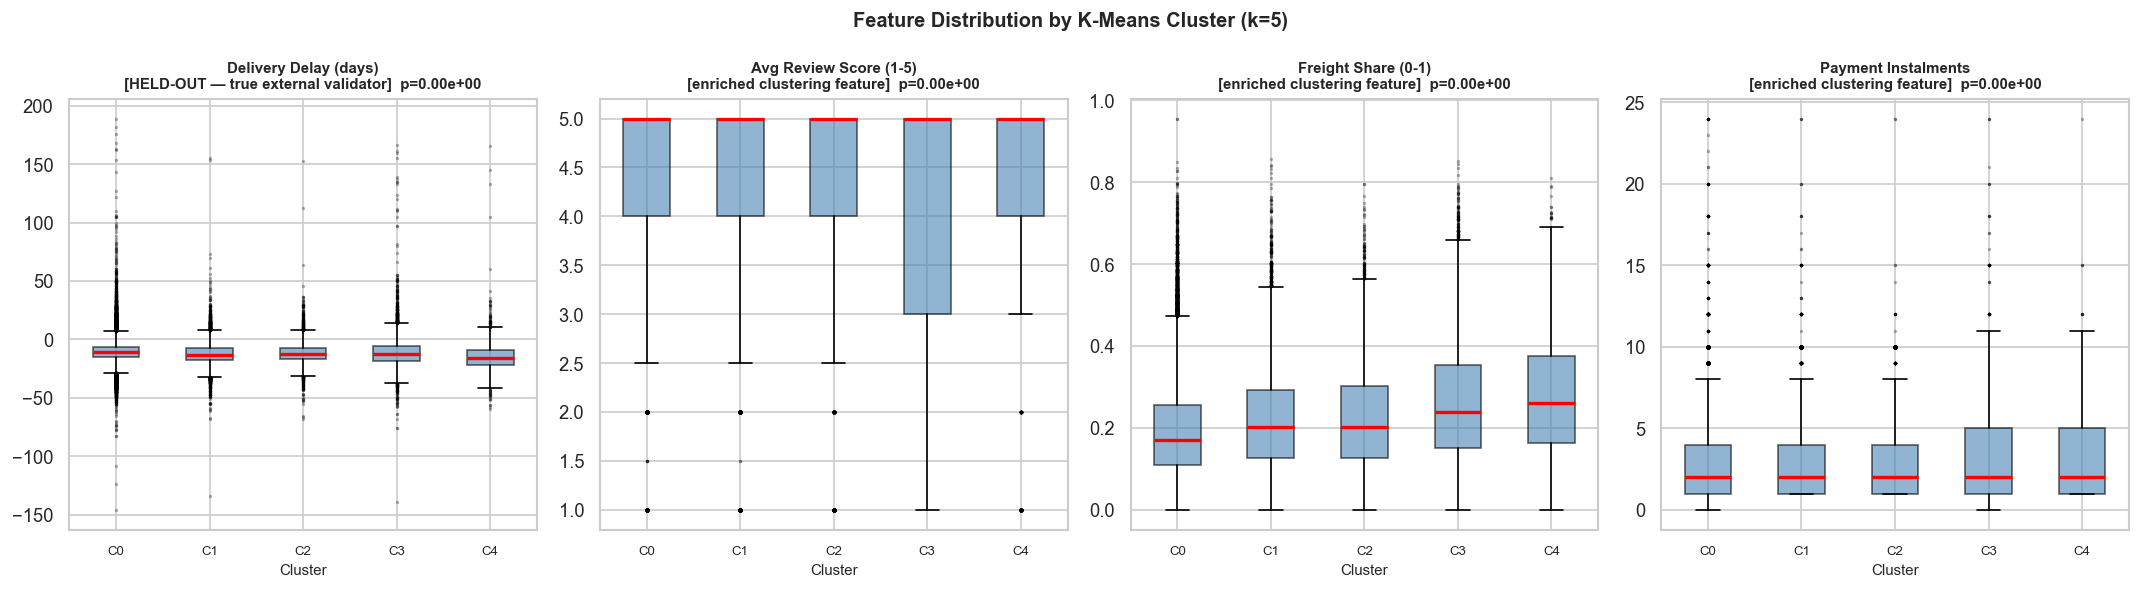

Saved: external_validation_boxplots.png


In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = {
    'delivery_delay_days':   'Delivery Delay (days)\n[HELD-OUT — true external validator]',
    'avg_review_score':      'Avg Review Score (1-5)\n[enriched clustering feature]',
    'freight_share':         'Freight Share (0-1)\n[enriched clustering feature]',
    'payment_installments':  'Payment Instalments\n[enriched clustering feature]',
}
cluster_ids = sorted(df_ext['cluster_kmeans'].unique())

for ax, col in zip(axes, ext_feat_cols):
    data_by_cluster = [df_ext.loc[df_ext['cluster_kmeans'] == k, col].dropna().values
                       for k in cluster_ids]
    ax.boxplot(data_by_cluster, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', lw=2),
               flierprops=dict(marker='.', ms=2, alpha=0.3))
    ax.set_xticklabels([f'C{k}' for k in cluster_ids], fontsize=8)
    ax.set_xlabel('Cluster', fontsize=9)

    row = anova_df[anova_df['Feature'] == col]
    p_str = f'  p={row["p-value"].values[0]:.2e}' if not row.empty else ''
    ax.set_title(f'{titles[col]}{p_str}', fontsize=9, fontweight='bold')

plt.suptitle(f'Feature Distribution by K-Means Cluster (k={best_k})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'external_validation_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: external_validation_boxplots.png')

## 10 · Cluster Profiling & Naming

Each cluster is described by its mean/median on all features, plus the dominant region.  
Segment names are assigned using data-driven thresholds (median / 75th percentile) of monetary value and order frequency.

In [24]:
profile = df.groupby('cluster_kmeans').agg(
    size                  = ('customer_id',          'count'),
    frequency_mean        = ('frequency',             'mean'),
    monetary_mean         = ('monetary',              'mean'),
    monetary_median       = ('monetary',              'median'),
    basket_mean           = ('avg_basket_size',       'mean'),
    n_cat_mean            = ('n_categories',          'mean'),
    avg_review_mean       = ('avg_review_score',      'mean'),
    freight_share_mean    = ('freight_share',         'mean'),
    installments_mean     = ('payment_installments',  'mean'),
).round(3)

profile['pct_customers'] = (profile['size'] / profile['size'].sum() * 100).round(1)

top_region = (
    df.groupby('cluster_kmeans')['region']
    .agg(lambda x: x.value_counts().index[0])
    .rename('top_region')
)
profile = profile.join(top_region)

print('=== Cluster Profiles ===')
print(profile.to_string())

=== Cluster Profiles ===
                 size  frequency_mean  monetary_mean  monetary_median  basket_mean  n_cat_mean  avg_review_mean  freight_share_mean  installments_mean  pct_customers    top_region
cluster_kmeans                                                                                                                                                                     
0               66200             1.0        150.478           99.900        1.144       0.991            4.186               0.195              2.829           68.6       Sudeste
1               13814             1.0        162.032          107.365        1.150       0.991            4.195               0.223              2.972           14.3           Sul
2                5624             1.0        177.085          114.360        1.152       0.986            4.133               0.227              2.943            5.8  Centro-Oeste
3                9044             1.0        201.520          130.010      

In [ ]:
def _name_segment(row):
    reg = row['top_region']
    if reg == 'Sudeste':
        return 'Urban Core Buyers'
    elif reg == 'Sul':
        return 'Southern Mid-Spend Buyers'
    elif reg == 'Centro-Oeste':
        return 'Central High-Value Buyers'
    elif reg == 'Nordeste':
        return 'Credit-Reliant Northeast Buyers'
    elif reg == 'Norte':
        return 'Remote Northern Premium Buyers'
    else:
        return 'Other Buyers'

profile['cluster_label'] = profile.apply(_name_segment, axis=1)

assert profile['cluster_label'].nunique() == len(profile), \
    f"Duplicate segment names! {profile['cluster_label'].tolist()}"

label_map = profile['cluster_label'].to_dict()
df['cluster_label'] = df['cluster_kmeans'].map(label_map)

print('=== Cluster Segment Names ===')
print(profile[['size', 'pct_customers', 'monetary_mean', 'avg_review_mean',
               'freight_share_mean', 'installments_mean',
               'top_region', 'cluster_label']].to_string())

profile.to_csv(OUT_DIR / 'cluster_profile_table.csv')

## 11 · Final Visualizations

PCA and t-SNE scatter plots coloured by K-Means cluster, plus a cluster-profile heatmap.

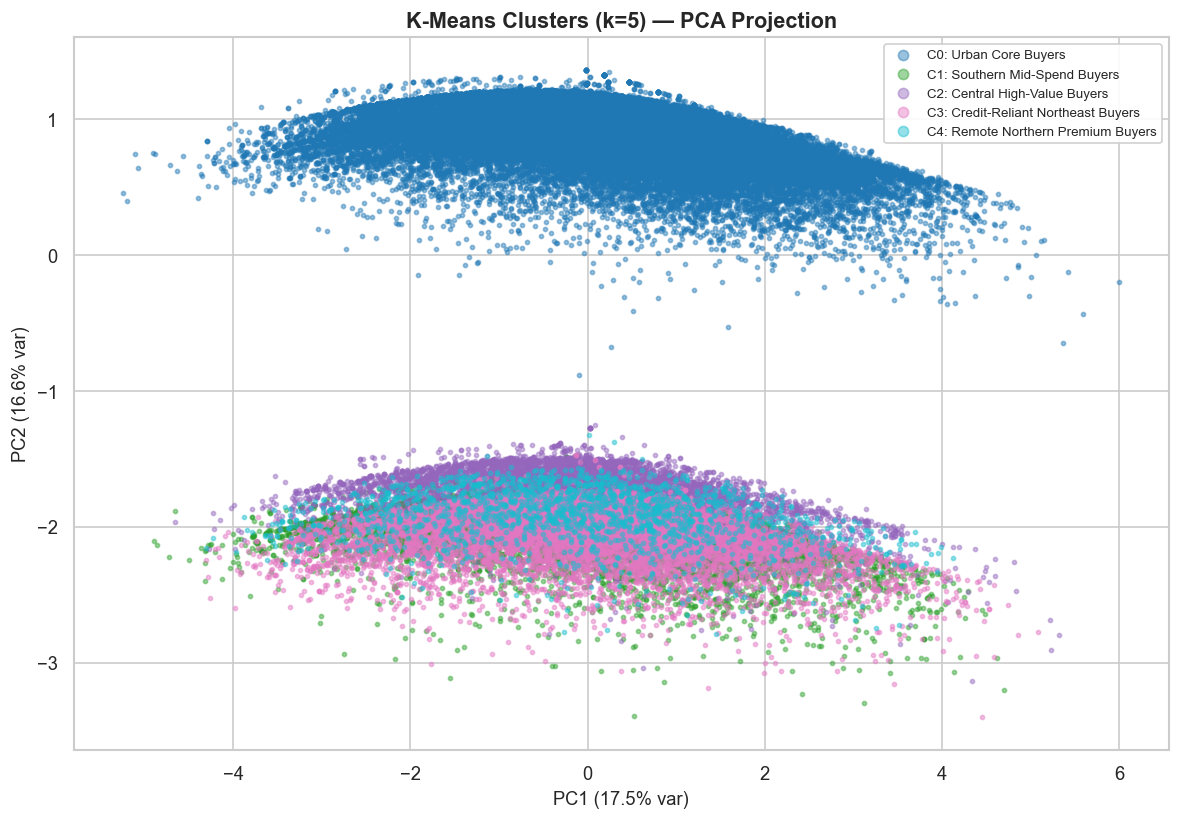

Saved: pca_kmeans_clusters.png


In [31]:
palette = cm.tab10(np.linspace(0, 0.9, best_k))

fig, ax = plt.subplots(figsize=(10, 7))
for k_idx in range(best_k):
    mask  = kmeans_labels == k_idx
    label = label_map.get(k_idx, f'Cluster {k_idx}')
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[palette[k_idx]], s=6, alpha=0.45,
        label=f'C{k_idx}: {label}', rasterized=True
    )

ax.set_xlabel(f'PC1 ({ev[0]:.1%} var)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]:.1%} var)', fontsize=11)
ax.set_title(f'K-Means Clusters (k={best_k}) — PCA Projection', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, markerscale=2.5, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_kmeans_clusters.png', bbox_inches='tight')
plt.show()
print('Saved: pca_kmeans_clusters.png')

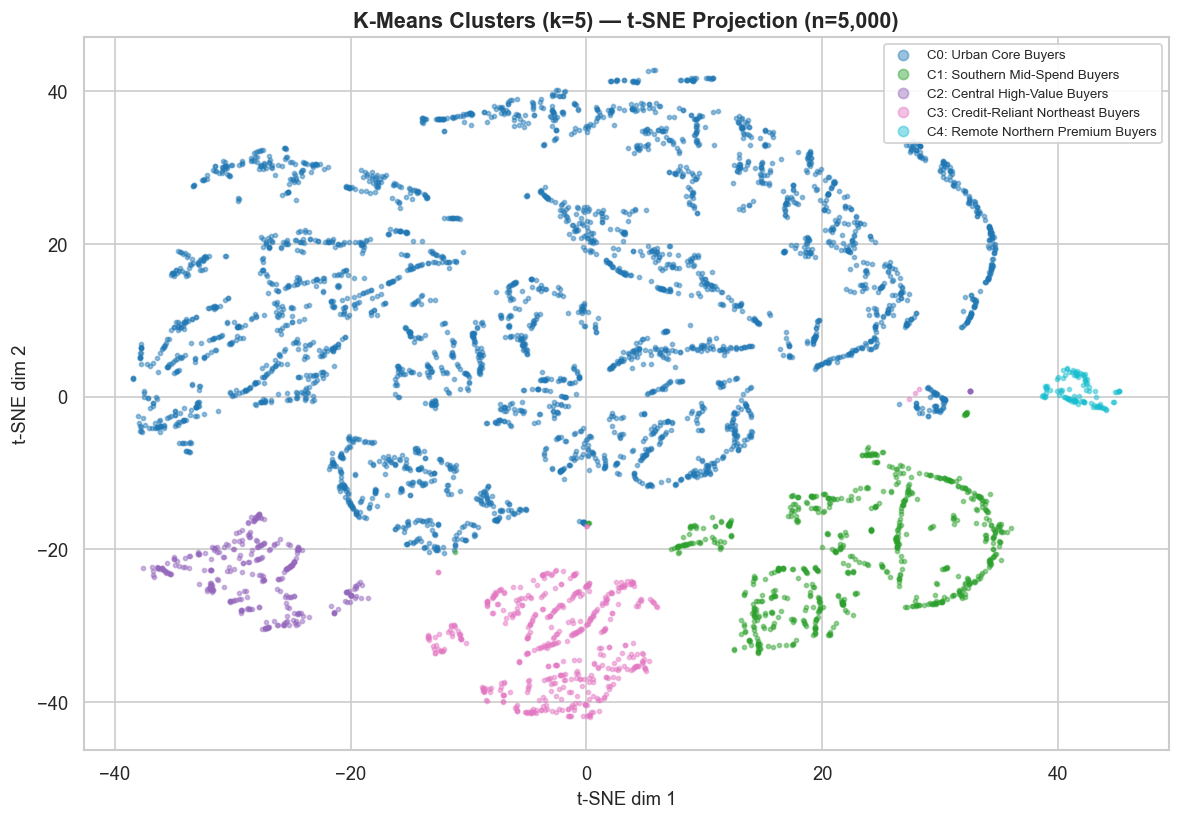

Saved: tsne_kmeans_clusters.png


In [32]:
tsne_labels = kmeans_labels[idx_tsne]

fig, ax = plt.subplots(figsize=(10, 7))
for k_idx in range(best_k):
    mask  = tsne_labels == k_idx
    label = label_map.get(k_idx, f'Cluster {k_idx}')
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[palette[k_idx]], s=6, alpha=0.45,
        label=f'C{k_idx}: {label}', rasterized=True
    )

ax.set_xlabel('t-SNE dim 1', fontsize=11)
ax.set_ylabel('t-SNE dim 2', fontsize=11)
ax.set_title(f'K-Means Clusters (k={best_k}) — t-SNE Projection (n={TSNE_N:,})',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, markerscale=2.5, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'tsne_kmeans_clusters.png', bbox_inches='tight')
plt.show()
print('Saved: tsne_kmeans_clusters.png')

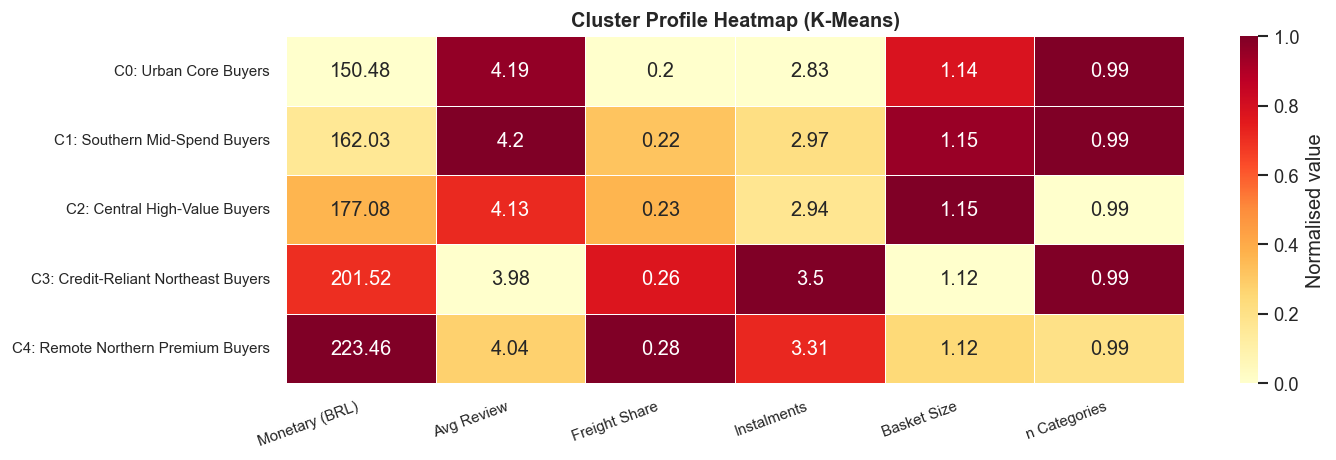

Saved: cluster_profile_heatmap.png


In [33]:
hm_cols   = ['monetary_mean', 'avg_review_mean', 'freight_share_mean',
             'installments_mean', 'basket_mean', 'n_cat_mean']
hm_labels = ['Monetary (BRL)', 'Avg Review', 'Freight Share',
             'Instalments', 'Basket Size', 'n Categories']

hm_data = profile[hm_cols].copy().astype(float)
hm_norm = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-9)
hm_norm.index = [f"C{k}: {label_map[k]}" for k in hm_norm.index]

fig, ax = plt.subplots(figsize=(12, max(4, best_k * 0.8)))
sns.heatmap(
    hm_norm, annot=hm_data.round(2), fmt='g',
    cmap='YlOrRd', ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Normalised value'},
    xticklabels=hm_labels,
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(hm_labels, rotation=20, ha='right', fontsize=9)
ax.set_title('Cluster Profile Heatmap (K-Means)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cluster_profile_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: cluster_profile_heatmap.png')

## 12 · Export Outputs

All files are written to `outputs/clustering/`.  
**`customer_cluster_assignments.csv`** is the primary handoff file consumed by M3 and M5.

In [ ]:
assignments = df[['customer_id', 'cluster_kmeans', 'cluster_label']].copy()
assignments.columns = ['customer_id', 'cluster_id', 'cluster_label']
assignments['algorithm'] = 'kmeans'
assignments.to_csv(OUT_DIR / 'customer_cluster_assignments.csv', index=False)
print(f'Saved: customer_cluster_assignments.csv  ({len(assignments):,} rows)')

all_asgn = df[['customer_id', 'cluster_kmeans', 'cluster_label',
               'cluster_hierarchical', 'cluster_dbscan']].copy()
all_asgn.columns = ['customer_id', 'cluster_kmeans', 'cluster_label_kmeans',
                    'cluster_hierarchical', 'cluster_dbscan']
all_asgn.to_csv(OUT_DIR / 'all_algorithm_assignments.csv', index=False)
print(f'Saved: all_algorithm_assignments.csv')

file_list = sorted(f.name for f in OUT_DIR.iterdir())
print(f"""
╔══════════════════════════════════════════════════════════╗
║          M4 Clustering — Final Summary                   ║
╠══════════════════════════════════════════════════════════╣
║  Customers clustered  : {len(df):>8,}                    ║
║  Best algorithm       : K-Means (k={best_k})             ║
║  Silhouette           : {sil_km:.4f}                     ║
║  Davies-Bouldin       : {db_km:.4f}                      ║
║  Stability (mean ARI) : {mean_ari:.4f}  {'PASS' if mean_ari>=0.50 else 'FAIL'}                    ║
╠══════════════════════════════════════════════════════════╣ 
║  Segment labels:                                         ║""")
for k_idx, name in sorted(label_map.items()):
    n = int((kmeans_labels == k_idx).sum())
    pct = n / len(kmeans_labels) * 100
    print(f'║    C{k_idx}: {name:<35}  {pct:4.1f}%  ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Output folder: outputs/clustering/                      ║')
for fname in file_list:
    print(f'║    {fname:<54}║')
print('╚══════════════════════════════════════════════════════════╝')